**Dupla**

| | Nome | Usuário no GitHub |
| --- | --- | --- |
| Integrante 1 | Daniel Teles de Oliveira | DanielTelesdeOlivera |
| Integrante 2 | João Victor Torres Soares | JTSoares |

**Checklist de entrega** (os detalhes estão na Seção 10)

- [ ] O notebook roda de cima para baixo em um kernel limpo (*Restart & Run All*) e foi salvo **com as saídas** (gráficos e tabelas).
- [ ] O repositório no GitHub tem `README.md`, `requirements.txt`, `lab_helpers.py` (opcional) e este notebook.
- [ ] Os dois integrantes têm commits no repositório.
- [ ] O link do repositório foi enviado na atividade do MS Teams.

## 1. Contexto

Neste laboratório vamos testar uma das afirmações mais debatidas na pesquisa sobre felicidade: a de que a satisfação com a vida segue uma **curva em U** ao longo da idade, e de que o formato dessa curva depende de onde a pessoa vive. Vocês vão construir o pipeline completo, dos dados brutos ao modelo ajustado, usando **Python, scikit-learn e Seaborn**.

Pesquisadores medem bem-estar com a **escada de Cantril** (*Cantril ladder*): a pessoa avalia sua vida atual de 0 (pior vida possível) a 10 (melhor vida possível). O **Gallup World Poll** faz essa pergunta em amostras nacionalmente representativas em mais de 140 países, e o **World Happiness Report (WHR)** publica as médias nacionais, em geral como médias móveis de três anos.

Duas histórias concorrentes sobre a idade aparecem nesses dados:

- **A curva em U clássica.** Estudos do Reino Unido e de outros países de renda alta mostram a felicidade caindo a partir dos 20 anos, até os 40 ou início dos 50, e depois subindo até se estabilizar por volta dos 70. As explicações incluem a pressão da meia-idade (emprego, filhos, cuidado com pais idosos) e a adaptação e as expectativas menores na velhice.
- **Um alvo em movimento.** O capítulo sobre idade do WHR 2024 mostra que a felicidade dos jovens (15 a 24 anos) na América do Norte caiu bastante desde 2006-2010, e hoje eles estão menos felizes que os mais velhos. Na Europa Central e Oriental aconteceu o oposto: a felicidade subiu em todas as idades. Quem nasceu depois de 1980 também relata avaliações de vida menores que as coortes anteriores.

*The Happiness Curve* é a versão popular, em formato de livro, da primeira história. O projeto de vocês é ver quanto de cada história sobrevive aos dados, e perceber o que renda, população e área do país mudam nesse quadro.

**Por que isso é um bom exercício de ML.** A pergunta se traduz em duas tarefas supervisionadas clássicas. Prever uma nota (0 a 10) a partir de idade e características do país é **regressão**. Prever se um grupo está acima ou abaixo de um limiar de felicidade é **classificação**. A curva em U também traz uma lição embutida: uma reta é o modelo errado para a idade, e vocês devem ser capazes de mostrar por quê.

## 2. Objetivos de aprendizagem e pré-requisitos

Ao final do laboratório, seremos capazes de construir, avaliar e explicar dois modelos do scikit-learn sobre um conjunto de dados combinado de várias fontes, dizendo com honestidade o que eles mostram e o que não mostram. Organize o tempo de laboratório, mais as leituras. Como o projeto é em dupla, a divisão de trabalho sugerida está abaixo.

Vocês serão capazes de:

- Combinar dados de pesquisa com indicadores do Banco Mundial usando uma chave de país, e auditar o *join* para achar países sem correspondência.
- Criar atributos (*features*) a partir de grandezas assimétricas (log do PIB per capita, log da população, log da área) e explicar o motivo.
- Ajustar uma regressão linear e visualizá-la com Seaborn, mostrando que um termo quadrático na idade supera a reta.
- Transformar uma variável numérica em rótulo binário, ajustar uma regressão logística e embrulhá-la em uma função reutilizável que devolve P(feliz) para uma idade e um país.
- Avaliar com uma divisão **agrupada por país**, para que o modelo seja testado em países que nunca viu.

**Pré-requisitos:** noções de pandas, o padrão `fit` / `predict` do scikit-learn e um laboratório anterior sobre divisão treino/teste.

In [ ]:
# Instalação (rode uma vez, se necessário). Remova o "#" da linha abaixo:
!pip install pandas numpy scikit-learn seaborn matplotlib requests openpyxl country_converter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lab_helpers import load_owid_age_data, build_country_table

sns.set_theme(style="whitegrid", context="talk")
RANDOM_STATE = 42   # semente fixa: seus resultados precisam ser reproduzíveis

## 3. Passo 0: leia antes de programar

Leiam as quatro fontes e escrevam **uma frase por fonte** respondendo à pergunta da tabela. Vocês vão reaproveitar essas frases na discussão final.

| Fonte | O que extrair |
| --- | --- |
| [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx) | Qual é exatamente a pergunta da escada de Cantril? Quem é entrevistado, e por que as notas nacionais são médias de três anos? |
| [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/) | Onde fica o mínimo da curva em U, e em quais dados de países de renda alta a afirmação se apoia? Quais mecanismos são propostos? |
| [World Happiness Report 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/) | Quais regiões quebram o padrão em U? O que é diferente em quem nasceu depois de 1980? Quais faixas etárias o relatório usa? |
| [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/) | Qual é o argumento central do livro, e vocês esperariam que ele valesse para um país de renda baixa? |

Dois detalhes que vocês vão usar depois. O capítulo de idade do WHR 2024 usa **quatro faixas etárias** (menos de 30, 30-44, 45-59 e 60+), então o conjunto de dados de vocês também terá quatro. E ele compara as médias de 2021-2023 com uma base de 2006-2010, então **sempre registrem a que anos os seus dados se referem**. Os números por faixa etária que vocês vão baixar na Parte 1 vêm do [Our World in Data](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), que republica os resultados do WHR 2024; deem uma olhada na visualização em tabela agora.

**Minhas notas de leitura**

1. **Gallup:** a escada Cantril busca responder a avaliação de vida pessoal em uma escala de 0 a 10. Os entrevistados são pessoas pesquisadas pelo Gallup World Poll. A pesquisa cobre mais de 160 países e territórios. A razão pelas notas nacionais serem medidas de três anos consiste na produção de estimativas mais precisas.
2. **WEF:** O mínimo da curva em U, em média, se apresenta entre a faixa de 20 e 40 anos, os dados se apoiam no Reino Unido e países semelhantes de alta renda.
Os mecanismos propostos, buscam outros fatores que influenciam sentimentos positivos e negativos ao longo da idade a felicidade, por exemplo é um fator que influencia na meia-idade pois adultos assumem responsabilidades adicionais no trabalho e família além de preocupações com o meio ambiente ao seu redor.
Além disso, percepções como as mudanças que ocorrem na vida e as alterações na interpretação desses eventos influenciam nos mecanismos propostos para o padrão em forma de U na felicidade ao longo das idades.
3. **WHR 2024:** As regiões que quebram o padrão em U são a América do Norte, a Europa Ocidental, a Europa Central e Oriental, o Sudeste Asiático e o Sul da Ásia. Entre as pessoas nascidas depois de 1980, observa-se uma queda na avaliação da felicidade com o passar dos anos, em direção oposta à observada entre as pessoas nascidas em períodos anteriores. O relatório se baseia nas seguintes faixas etárias: 15–29 anos, 30–44 anos, 45–59 anos e 60 anos ou mais.
4. **The Happiness Curve:** O argumento central do livro é que a felicidade humana ao longo da vida segue uma curva em formato de U, sendo a felicidade um fenômeno humano transcultural, impulsionado por mudanças psicológicas e biológicas ligadas à idade. Entretanto, em países de baixa renda, a curva demonstra o seguinte comportamento: picos de infelicidade na meia-idade e a recuperação na velhice são fortemente modulados, agravados ou atenuados pelas duras realidades da pobreza, da saúde precária e da ausência de seguridade social. Logo, esse argumento deve ser considerado levando em consideração o peso e a importância dos fatores mencionados, para a influência da felicidade ao longo dos anos

## 4. Fluxo de trabalho sugerido

Trabalhem em seis etapas, em um único notebook, com uma célula de texto (markdown) com as **palavras de vocês** acima de cada célula de código. Cada etapa produz algo que dá para conferir antes de seguir.

**0 Ler → 1 Baixar os dados → 2 Enriquecer (PIB, população, área) → 3 Regressão linear + gráficos → 4 Regressão logística → 5 Discutir os limites**

| Processo | Etapa | Vocês terminaram quando | Tempo sugerido |
| --- | --- | --- | --- |
| ASK | 0 Ler | Há uma frase por fonte (Seção 3) | 60 min |
| GET | 1 Baixar | `age` tem 4 linhas por país e nenhum `ladder_mean` faltando | 30 min |
| EXPLORE | 2 Enriquecer | Todo país mantido tem PIB, população e área; a lista de países descartados foi impressa | 40 min |
| MODEL | 3 Linear | Duas figuras do Seaborn e uma tabela comparando três modelos com R² e RMSE em validação cruzada | 60 min |
| MODEL | 4 Logística | `check_happiness(country, age)` devolve uma probabilidade, e vocês reportam acurácia e AUC em países não vistos | 60 min |
| COMMUNICATE | 5 Discutir | Meia página respondendo às perguntas da Seção 9 | 30 min |

> É bem factível terminar o projeto durante o LAB trabalhando em equipe

**Escolhas de projeto já feitas por nós**, para que os resultados sejam comparáveis entre as duplas: a variável-alvo é a média da escada de Cantril, a idade entra como o **ponto médio** da faixa, o PIB é per capita em PPC (paridade do poder de compra) e todas as grandezas assimétricas passam por logaritmo. Vocês podem mudar qualquer uma delas, e podem acrescentar os dados extras que acharem úteis (veja o fim da Seção 6), desde que informem isso no relatório.

**Sugestão de divisão do trabalho na dupla.** Os dois fazem as leituras (Passo 0) e a discussão final juntos. A pessoa A fica com as Partes 1 e 3 (dados e regressão linear); a pessoa B, com as Partes 2 e 4 (enriquecimento e regressão logística). Antes de seguir para a etapa seguinte, um revisa o código do outro. Usem branches e *pull requests* no GitHub, ou pelo menos façam commits frequentes com mensagens claras.

## 5. Parte 1: configuração e download dos dados

Os dados por idade são **gratuitos e públicos**: o Our World in Data (OWID) republica os resultados por faixa etária do WHR 2024, enquanto os downloads do próprio WHR não trazem divisão por idade. A [página de compartilhamento de dados do WHR](https://www.worldhappiness.report/data-sharing/) oferece a planilha da Figura 2.1 (médias nacionais de três anos desde 2012) e apêndices estatísticos. Vocês vão combinar duas fontes:

| Fonte | O que entrega | Como obter |
| --- | --- | --- |
| [OWID: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table) | Média da escada de Cantril em quatro faixas etárias (até 29, 30-44, 45-59, 60+) em cerca de 195 países, média de 2021-2023, com códigos de país ISO3. Licença CC BY. | Download de CSV, em formato largo (uma linha por país) |
| [Planilha da Figura 2.1 do WHR](https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx) | Nota nacional geral (médias de três anos desde 2012), intervalos de confiança e fatores explicativos | Arquivo Excel |
| Arquivo do professor (opcional) | As mesmas faixas etárias para outros anos, em formato longo | Fornecido em aula |

O arquivo do OWID tem as colunas `Entity`, `Code`, `Year`, `Up to 29 years`, `30-44 years`, `45-59 years` e `60+ years`. `Code` é o código de país ISO3, então dá para juntar com os dados do Banco Mundial sem comparar nomes.

5.1: Baixar os arquivos de dados e carregar no data frame Pandas, inspecionar os dados...

5.1: Abram a [visualização em tabela do OWID](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), leiam o CSV vocês mesmos e inspecionem. Depois transformem de largo para longo (wide data) com `melt`, de modo que haja uma linha por país e faixa etária. Por fim, comparem o resultado com `load_owid_age()`, que faz o mesmo e ainda descarta linhas sem código de país.

> Dica: usar LIB `requests` para baixar os dados no Jupyter Notebook (Colab) - https://requests.readthedocs.io/en/latest/ <br>
> Ou usar `wget` ou `curl` terminal do Linux

A equipe pode encontrar baixar e combinar outras fontes de dados sobre os países para obter GDP, popuação, território, etc... para enriquecer os dados...

> Estamos trabalhando com dados reais... as fontes de dados podem mudar os formatos ou publicar informações mais atuais e também modificar a estrutura de dados... Sinta-se livre para utilizar fontes de dados adicionais...


## Extração e transformação dos dados OWID

In [ ]:
from lab_helpers import OWID_AGE_URL, load_owid_age_data
import pandas as pd
import requests
import io

resposta = requests.get(OWID_AGE_URL, headers={"User-Agent": "Mozilla/5.0"})
raw = pd.read_csv(io.BytesIO(resposta.content))

print(raw.shape)
display(raw.head())
print(raw.isna().sum())


(143, 7)


,Entity,Code,Year,Up to 29 years,30-44 years,45-59 years,60+ years
0,Afghanistan,AFG,2023,1.827,1.617,1.681,1.456
1,Albania,ALB,2023,6.358,5.289,4.704,4.643
2,Algeria,DZA,2023,5.379,5.290,5.261,5.631
3,Argentina,ARG,2023,6.746,6.119,5.676,5.948
4,Armenia,ARM,2023,6.245,5.448,5.032,4.865


Entity            0
Code              0
Year              0
Up to 29 years    0
30-44 years       0
45-59 years       0
60+ years         0
dtype: int64


In [ ]:

age = load_owid_age_data()   # formato longo: country, iso3, year, age_group, ladder_mean, window
print(age.groupby("iso3").size().value_counts())   # esperado: todo país com 4 linhas

4    143
Name: count, dtype: int64


5.3: Baixem a planilha da Figura 2.1 com `pd.read_excel`. **Visualizar as colunas antes de usar qualquer uma**, porque os nomes mudam entre as edições do relatório e não devem ser copiados de um tutorial antigo. Usem a planilha como verificação de sanidade: a média das quatro faixas etárias de um país deve ficar perto da nota geral dele, mas não idêntica, porque as fontes ponderam e definem as janelas de tempo de formas diferentes.

# Extração dos dados da WHR

In [ ]:
from io import BytesIO

url_whr = "https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx"

response = requests.get(
    url_whr,
    headers={"User-Agent": "Mozilla/5.0"}
)
response.raise_for_status()

df_whr = pd.read_excel(BytesIO(response.content))

# Converte para CSV
df_whr.to_csv("WHR26_Data_Figure_2.1.csv", index=False)


df_whr.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


In [ ]:
df_whr.columns

Index(['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)',
       'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita',
       'Explained by: Social support', 'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')

# Comparação da média das 4 faixas etárias de cada país com a nota geral com uma tabela

In [ ]:
# Média das 4 faixas etárias por país
age_mean = (
    age.groupby(["country", "iso3"])["Happiness"]
    .mean()
    .reset_index()
    .rename(columns={
        "Happiness": "Média das 4 faixas etárias"
    })
)


# Nota geral do WHR 2026

whr_geral = (
    df_whr[
        ["Country name", "Life evaluation (3-year average)"]
    ]
    .drop_duplicates(subset=["Country name"])
    .rename(columns={
        "Country name": "country",
        "Life evaluation (3-year average)": "Nota geral"
    })
)

tabela_comparacao = age_mean.merge(
    whr_geral,
    on="country",
    how="inner"
)



# Garante uma única linha por país

tabela_comparacao = (
    tabela_comparacao
    .drop_duplicates(subset=["country"])
    .sort_values("country")
)

tabela_comparacao = tabela_comparacao[
    [
        "country",
        "Média das 4 faixas etárias",
        "Nota geral"
    ]
]

tabela_comparacao["Média das 4 faixas etárias"] = (
    tabela_comparacao["Média das 4 faixas etárias"].round(2)
)

tabela_comparacao["Nota geral"] = tabela_comparacao["Nota geral"].round(2)


display(tabela_comparacao)

,country,Média das 4 faixas etárias,Nota geral
0,Afghanistan,1.65,1.45
1,Albania,5.25,5.66
2,Algeria,5.39,5.71
3,Argentina,6.12,6.43
4,Armenia,5.40,5.58
...,...,...,...
127,Uzbekistan,6.26,6.28
128,Venezuela,5.57,5.76
129,Yemen,3.49,3.53
130,Zambia,3.17,4.11


## 6. Parte 2: enriquecer com PIB, população e tamanho do país

A felicidade varia muito mais **entre países** do que **entre faixas etárias**, então vocês precisam de controles no nível do país antes que o efeito da idade signifique alguma coisa. Vocês vão buscar três indicadores do Banco Mundial pela API pública e juntá-los pelo código **ISO3**, e não pelo nome.

| Atributo | Indicador do Banco Mundial | Por que transformar |
| --- | --- | --- |
| PIB per capita, PPC (dólares internacionais constantes) | `NY.GDP.PCAP.PP.KD` | A renda tem retornos decrescentes, então use `log` |
| População | `SP.POP.TOTL` | Varia em 5 ordens de grandeza (Islândia a Índia), então use `log` |
| Área terrestre (km²) | `AG.LND.TOTL.K2` | Mesma assimetria da população, então use `log` |

`lab_helpers.build_country_table()` chama a API, guarda o último valor não faltante de 2019 a 2023 para cada indicador e descarta os agregados regionais (como "World" e "Arab World") que a API mistura com os países. **Leiam o código antes de rodar**: a resposta é uma lista de dois elementos, com os metadados primeiro e os registros depois.


**Tarefa 2.1.** Confiram as chaves de país. O arquivo do OWID já traz códigos ISO3 na coluna `iso3`, então os dados por idade não precisam de comparação de nomes. Usem `to_iso3` só para fontes que trazem apenas o nome do país (a planilha do WHR, por exemplo), e leiam a lista de nomes sem correspondência que ela imprime.

In [ ]:
#Biblioteca necessaria para padronizacao dos paises convertendo para ISO3
#Remover o comentario para realizar a instalacao
#!pip install country_converter -q
import country_converter as coco

def to_iso3(series):
    # Converte os nomes para ISO# e preenche com 'N/A' o que não for encontrado
    return coco.convert(names=series, to='ISO3', not_found='N/A')

paises_whr = df_whr["Country name"].unique()
codigos_iso3 = to_iso3(paises_whr)
mapa_paises = dict(zip(paises_whr, codigos_iso3))
df_whr["iso3"] = df_whr["Country name"].map(mapa_paises)

paises_sem_iso3 = df_whr[df_whr["iso3"] == "N/A"]["Country name"].unique()
display(df_whr[["Country name", "iso3"]].head())

,Country name,iso3
0,Finland,FIN
1,Iceland,ISL
2,Denmark,DNK
3,Costa Rica,CRI
4,Sweden,SWE



**Tarefa 2.2.** Juntem a tabela de idade com a tabela de países usando `validate="many_to_one"`. Depois imprimam os países que perderam dados porque o Banco Mundial não tem valor para eles.

In [ ]:
from lab_helpers import fetch_wb, build_country_table

paises_wb = build_country_table()
df = age.merge(paises_wb, on="iso3", how="left", validate="many_to_one")

#Paises que nao possuem dados no Banco Mundial
paises_perdidos = df[df[["gdp_pc", "pop", "area_km2"]].isna().any(axis=1)]["country"].unique()
df = df.dropna(subset=["gdp_pc", "pop", "area_km2"]).copy()


Baixando dados do Banco Mundial...


**Tarefa 2.3**
Criem os atributos: age_mid a partir do dicionário AGE_MID do lab_helpers.py, age_sq, log_gdp_pc, log_pop, log_area e pop_density = pop / area_km2.

In [ ]:
from lab_helpers import AGE_MID

In [ ]:

# Criando as colunas derivadas pedidas no roteiro
df["age_mid"] = df["Age_Group"].map(AGE_MID).astype(float)
df["age_sq"] = df["age_mid"] ** 2
df["log_gdp_pc"] = np.log(df["gdp_pc"])
df["log_pop"] = np.log(df["pop"])
df["log_area"] = np.log(df["area_km2"])
df["pop_density"] = df["pop"] / df["area_km2"]

#Base de dados final enriquecida
display(df.head())

,country,iso3,year,Age_Group,Happiness,gdp_pc,pop,area_km2,age_mid,age_sq,log_gdp_pc,log_pop,log_area,pop_density,happy
0,Afghanistan,AFG,2023,Up to 29 years,1.827,1983.812620,41454761.0,652230.0,24.5,600.25,7.592776,17.540113,13.388153,63.558501,0
1,Afghanistan,AFG,2023,30-44 years,1.617,1983.812620,41454761.0,652230.0,37.0,1369.00,7.592776,17.540113,13.388153,63.558501,0
2,Afghanistan,AFG,2023,45-59 years,1.681,1983.812620,41454761.0,652230.0,52.0,2704.00,7.592776,17.540113,13.388153,63.558501,0
3,Afghanistan,AFG,2023,60+ years,1.456,1983.812620,41454761.0,652230.0,70.0,4900.00,7.592776,17.540113,13.388153,63.558501,0
4,Albania,ALB,2023,Up to 29 years,6.358,20501.647073,2411658.0,27400.0,24.5,600.25,9.928261,14.695825,10.218298,88.016715,1


## 7. Parte 3: regressão linear e visualização com Seaborn

O objetivo é mostrar, com gráficos e números de validação cruzada, **se a idade precisa de uma curva em vez de uma reta**, e quanto do quadro é explicado pela riqueza em vez de pela idade. Vocês vão ajustar três modelos aninhados com `sklearn.linear_model.LinearRegression`:

$$\text{M1: } \hat y = \beta_0 + \beta_1\,\text{idade} \qquad$$

$$\text{M2: } \hat y = \beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2$$

$$\text{M3: } \hat y = \text{M2} + \beta_3 \ln(\text{PIB pc}) + \beta_4 \ln(\text{pop}) + \beta_5 \ln(\text{área})$$

Em M2 e M3, a curva ajustada vira em **idade = −β₁ / (2β₂)**. Essa é a estimativa de vocês para a idade em que a felicidade atinge o mínimo, e dá para compará-la com os 40 e poucos ou início dos 50 anos citados no artigo do WEF.

**Tarefa 3.1. Reta ou curva.** Desenhem lado a lado dois gráficos de dispersão de `ladder_mean` contra `age_mid`, um com `order=1` e outro com `order=2`. O Seaborn ajusta e desenha o polinômio para vocês.

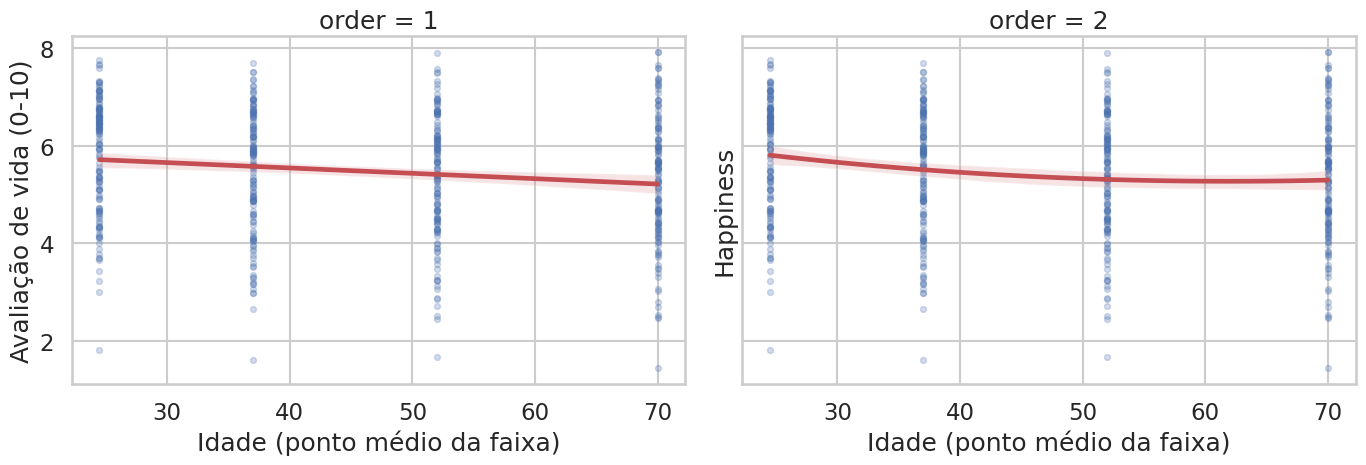

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, order in zip(axes, [1, 2]):
    sns.regplot(data=df, x="age_mid", y="Happiness", order=order, ax=ax,
                scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "C3"})
    ax.set_title(f"order = {order}")
    ax.set_xlabel("Idade (ponto médio da faixa)")
axes[0].set_ylabel("Avaliação de vida (0-10)")
plt.tight_layout()
plt.show()

**Tarefa 3.2. O perfil da idade dentro dos países.** Países ricos e pobres ficam em alturas muito diferentes, o que pode esconder o padrão da idade. Subtraiam a média de cada país e plotem o desvio por faixa de renda com `sns.lmplot(..., col="income_tier", order=2)`. Criem as faixas com `pd.qcut(df["gdp_pc"], 3, labels=[...])`.

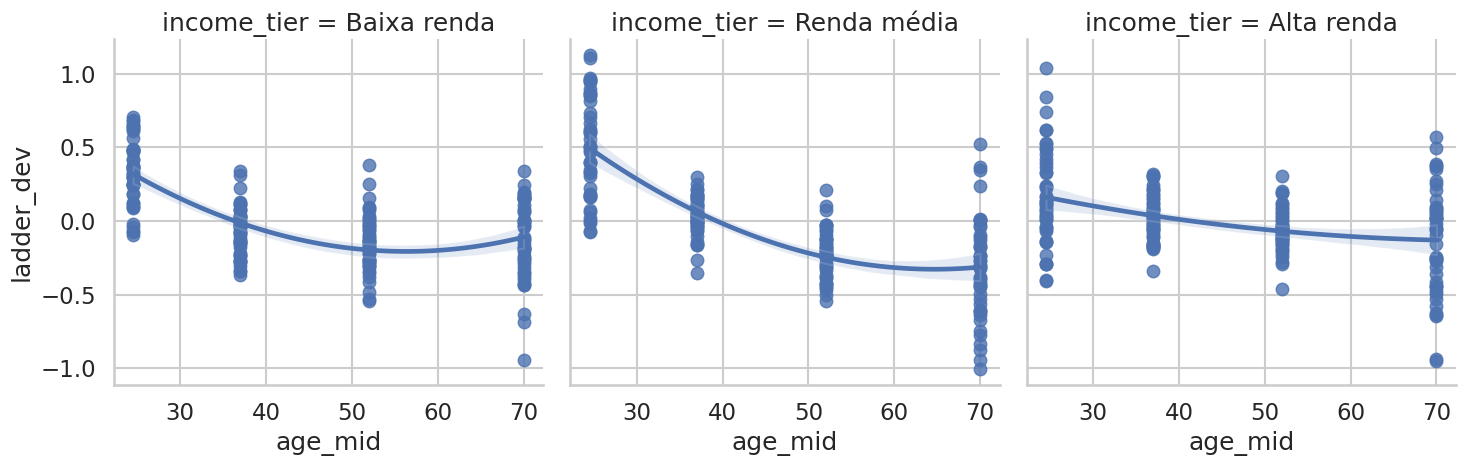

In [ ]:
df["ladder_dev"] = df["Happiness"] - df.groupby("iso3")["Happiness"].transform("mean")
df["income_tier"] = pd.qcut(df["gdp_pc"], 3, labels=["Baixa renda", "Renda média", "Alta renda"])

sns.lmplot(data=df, x="age_mid", y="ladder_dev", col="income_tier", order=2)

**Tarefa 3.3. Comparem três modelos em países não vistos.** Uma divisão aleatória de linhas colocaria as outras faixas etárias do mesmo país no treino, então dividam **por país** com `GroupKFold`. Reportem R² e RMSE em validação cruzada para M1, M2 e M3, e depois repitam M1 e M2 com `ladder_dev` como alvo.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error


def cv_scores(features, target="Happiness", k=5):
    # Validação cruzada agrupada por país:
    # um país inteiro fica no treino OU no teste.
    pred = cross_val_predict(
        LinearRegression(),
        df[features],
        df[target],
        groups=df["iso3"],
        cv=GroupKFold(n_splits=k)
    )

    return (
        r2_score(df[target], pred),
        mean_squared_error(df[target], pred) ** 0.5,
        pred
    )


# Criar idade²
df["age_mid_sq"] = df["age_mid"] ** 2

# Criar variáveis logarítmicas
df["log_gdp_pc"] = np.log(df["gdp_pc"])
df["log_pop"] = np.log(df["pop"])
df["log_area"] = np.log(df["area_km2"])


models = {
    "M1 idade": ["age_mid"],
    "M2 idade + idade²": ["age_mid", "age_mid_sq"],
    "M3 M2 + log PIB + log pop + log área": [
        "age_mid",
        "age_mid_sq",
        "log_gdp_pc",
        "log_pop",
        "log_area"
    ]
}


# Avaliar M1, M2 e M3 com Hapiness
results = []

for name, features in models.items():
    r2, rmse, pred = cv_scores(features, target="Happiness")

    results.append({
        "Modelo": name,
        "Target": "Happiness",
        "R2": r2,
        "RMSE": rmse
    })


# Repetir M1 e M2 com ladder_dev
for name in ["M1 idade", "M2 idade + idade²"]:
    features = models[name]

    r2, rmse, pred = cv_scores(features, target="ladder_dev")

    results.append({
        "Modelo": name,
        "Target": "ladder_dev",
        "R2": r2,
        "RMSE": rmse
    })


# Tabela final
results_df = pd.DataFrame(results)

results_df

,Modelo,Target,R2,RMSE
0,M1 idade,Happiness,0.014392,1.242056
1,M2 idade + idade²,Happiness,0.019127,1.239069
2,M3 M2 + log PIB + log pop + log área,Happiness,0.628225,0.762832
3,M1 idade,ladder_dev,0.304392,0.279544
4,M2 idade + idade²,ladder_dev,0.370358,0.265959


Tarefa 3.4. Riqueza e resíduos. Ajustem M3 com todas as linhas e imprimam os coeficientes e a idade do mínimo. Depois desenhem a riqueza contra a felicidade (x="log_gdp_pc", colorido por age_group), além de previsto contra real e um gráfico de resíduos usando as previsões da validação cruzada. Identifiquem os três países com os maiores resíduos e sugiram o que o modelo não está capturando.

              Modelo      Target        R2      RMSE
0           M1 idade   Happiness  0.014392  1.242056
1  M2 idade + idade²   Happiness  0.019127  1.239069
2                 M3   Happiness  0.628225  0.762832
3           M1 idade  ladder_dev  0.304392  0.279544
4  M2 idade + idade²  ladder_dev  0.370358  0.265959

Coeficientes do M3:
age_mid: -0.0471
age_mid_sq: 0.0004
log_gdp_pc: 0.8727
log_pop: -0.0865
log_area: 0.0923
Idade do mínimo: 61.95


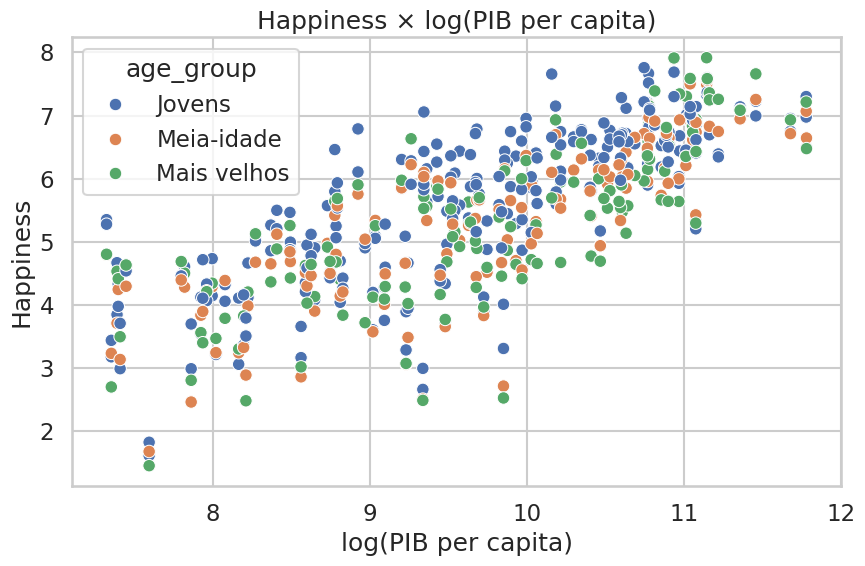

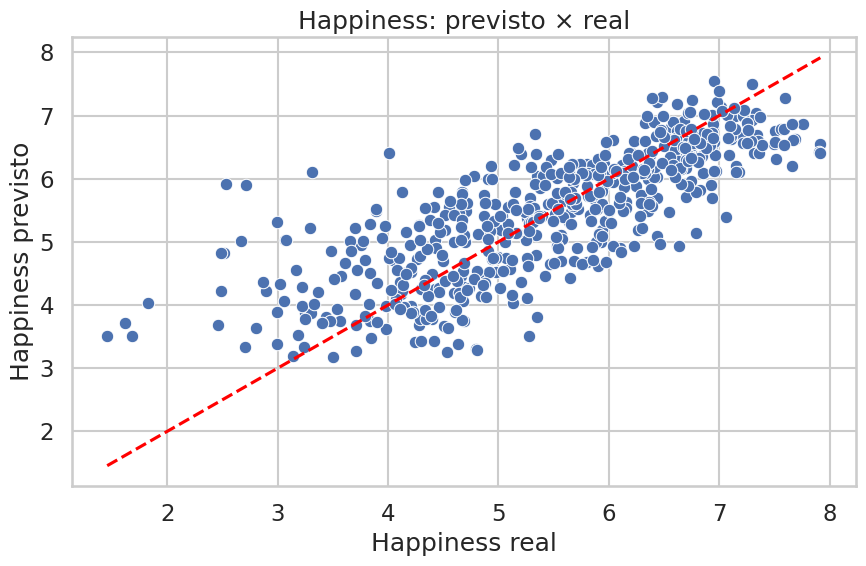

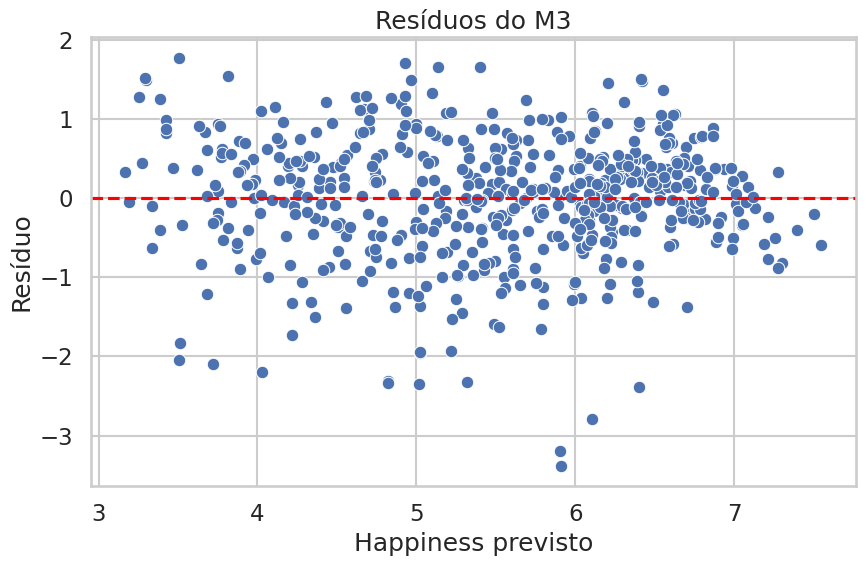


3 países com maiores resíduos:
   iso3  Happiness  previsto   residuo
59  BWA      2.528  5.909333 -3.381333
58  BWA      2.717  5.907080 -3.190080
57  BWA      3.312  6.102554 -2.790554


In [ ]:
df_model["age_group"] = pd.qcut(
    df_model["age_mid"], 3,
    labels=["Jovens", "Meia-idade", "Mais velhos"]
)

df_model["age_mid_sq"] = df_model["age_mid"] ** 2
df_model["log_gdp_pc"] = np.log(df_model["gdp_pc"])
df_model["log_pop"] = np.log(df_model["pop"])
df_model["log_area"] = np.log(df_model["area_km2"])

# FUNÇÃO DE VALIDAÇÃO CRUZADA

def cv_scores(features, target="Happiness", k=5):
    pred = cross_val_predict(
        LinearRegression(),
        df_model[features],
        df_model[target],
        groups=df_model["iso3"],
        cv=GroupKFold(n_splits=k)
    )

    return (
        r2_score(df_model[target], pred),
        mean_squared_error(df_model[target], pred) ** 0.5,
        pred
    )


models = {
    "M1 idade": ["age_mid"],
    "M2 idade + idade²": ["age_mid", "age_mid_sq"],
    "M3": [
        "age_mid", "age_mid_sq",
        "log_gdp_pc", "log_pop", "log_area"
    ]
}

# R2 E RMSE DOS MODELOS

results = []

for name, features in models.items():
    r2, rmse, _ = cv_scores(features)
    results.append([name, "Happiness", r2, rmse])

for name in ["M1 idade", "M2 idade + idade²"]:
    r2, rmse, _ = cv_scores(models[name], target="ladder_dev")
    results.append([name, "ladder_dev", r2, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Modelo", "Target", "R2", "RMSE"]
)

print(results_df)

# AJUSTAR M3 E CALCULAR IDADE DO MÍNIMO

m3_features = models["M3"]

m3 = LinearRegression().fit(
    df_model[m3_features],
    df_model["Happiness"]
)

print("\nCoeficientes do M3:")

for feature, coef in zip(m3_features, m3.coef_):
    print(f"{feature}: {coef:.4f}")

b1 = m3.coef_[m3_features.index("age_mid")]
b2 = m3.coef_[m3_features.index("age_mid_sq")]

idade_min = -b1 / (2 * b2)

print(f"Idade do mínimo: {idade_min:.2f}")


# GRÁFICO 1 — PIB × HAPPINESS

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_model,
    x="log_gdp_pc",
    y="Happiness",
    hue="age_group"
)

plt.title("Happiness × log(PIB per capita)")
plt.xlabel("log(PIB per capita)")
plt.ylabel("Happiness")
plt.tight_layout()
plt.show()

# GRÁFICO 2 — PREVISTO × REAL

_, _, pred_m3 = cv_scores(m3_features)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=df_model["Happiness"],
    y=pred_m3
)

limites = [
    min(df_model["Happiness"].min(), pred_m3.min()),
    max(df_model["Happiness"].max(), pred_m3.max())
]

plt.plot(limites, limites, "--", color="red")

plt.title("Happiness: previsto × real")
plt.xlabel("Happiness real")
plt.ylabel("Happiness previsto")
plt.tight_layout()
plt.show()


# GRÁFICO 3 — RESÍDUOS + 3 MAIORES

residuos = df_model["Happiness"] - pred_m3

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=pred_m3,
    y=residuos
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Resíduos do M3")
plt.xlabel("Happiness previsto")
plt.ylabel("Resíduo")
plt.tight_layout()
plt.show()


top3 = (
    df_model[["iso3", "Happiness"]]
    .assign(
        previsto=pred_m3,
        residuo=residuos,
        residuo_abs=residuos.abs()
    )
    .sort_values("residuo_abs", ascending=False)
    .head(3)
)

print("\n3 países com maiores resíduos:")
print(top3[["iso3", "Happiness", "previsto", "residuo"]])

**O que esperar, e por quê.** As diferenças entre países são grandes perto das diferenças entre idades, então a idade sozinha explica muito pouco da nota bruta, mesmo quando o formato dela é claro dentro dos países. Se o R² de M1 e M2 ficar perto de zero enquanto o gráfico dentro dos países mostra uma curva clara, isso é um **resultado** a explicar no relatório, não um erro.

**Minhas conclusões da Parte 3**:
Os resultados da Parte 3 indicam que a relação entre idade e felicidade apresenta um comportamento não linear, porém a idade, quando analisada isoladamente, possui baixo poder explicativo sobre a avaliação de vida entre diferentes países. O modelo M1, baseado apenas na idade, apresentou e RMSE de 1,242, enquanto a inclusão do termo quadrático no M2 elevou o (R^2) para apenas 0,019, com RMSE de 1,239. Portanto, embora a representação por uma curva seja mais adequada para capturar o comportamento da idade, a variação entre países permanece como um fator muito mais relevante para explicar os níveis absolutos de felicidade.

Essa diferença fica mais evidente quando as médias de cada país são removidas. Utilizando ladder_dev, o M1 apresentou (R^2=0,304), enquanto o M2 alcançou (R^2=0,370), reduzindo o RMSE de 0,280 para 0,266. Isso indica que, após controlar as diferenças estruturais existentes entre os países, a idade passa a explicar uma parcela consideravelmente maior da variação da felicidade, e o termo quadrático melhora a capacidade do modelo de representar seu comportamento ao longo da idade.

A inclusão das variáveis de contexto no M3 produziu a maior alteração nos resultados. Com idade, idade ao quadrado, logaritmo do PIB per capita, população e área territorial, o modelo alcançou (R^2=0,628) e RMSE de 0,763 para a felicidade absoluta. Entre os coeficientes estimados, o PIB per capita apresentou coeficiente de 0,8727, enquanto os coeficientes da idade foram -0,0471 para age_mid e 0,0004 para age_mid_sq, resultando em uma estimativa de mínimo da curva em aproximadamente 61,95 anos. Esse resultado evidencia que as condições econômicas e estruturais dos países são importantes para explicar as diferenças observadas nas avaliações de vida e que a relação com a idade não deve ser interpretada de forma isolada.

Por fim, a análise dos resíduos mostrou que o modelo ainda não captura completamente as particularidades de determinados países. Os maiores resíduos em valor absoluto foram observados para registros do Botswana, indicando que fatores não incluídos nas variáveis utilizadas podem contribuir para explicar diferenças na avaliação de vida que não são capturadas pela idade, pelo PIB, pela população ou pela área territorial.

Assim, a Parte 3 demonstra que a idade apresenta uma relação curvilínea com a felicidade, mas as diferenças entre países exercem papel substancial na variação da avaliação de vida. A comparação entre os modelos mostra ainda que o controle das características dos países é fundamental para interpretar adequadamente a relação entre idade e felicidade, evitando atribuir à idade diferenças que podem estar associadas ao contexto socioeconômico e estrutural de cada país.
...

## Parte 4: regressão logística, feliz ou não por idade e país
A regressão linear prevê uma nota; a regressão logística prevê a probabilidade de um grupo ser "feliz", o que exige um rótulo sim/não. Vocês vão definir o rótulo, treinar LogisticRegression e embrulhar o resultado em uma função que uma pessoa sem experiência em programação consiga usar: dê um país e uma idade, receba uma probabilidade.

$$P(\text{feliz} = 1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2 + \beta_3 \ln \text{PIB} + \beta_4 \ln \text{pop} + \beta_5 \ln \text{área})}}$$

**Tarefa 4.1. Definam o rótulo.** Chamem um grupo de feliz quando `ladder_mean` estiver acima da **mediana** de todos os grupos. A mediana dá classes balanceadas, então a acurácia faz sentido. Imprimam o limiar e a proporção de linhas felizes, e escrevam uma frase sobre como as conclusões mudariam com um limiar fixo, como 6,0.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

#Definicao do rotulo (Feliz ou Nao)
THRESHOLD = df["Happiness"].median()
df["happy"] = (df["Happiness"] > THRESHOLD).astype(int)

print(f"Limiar de Felicidade (Mediana): {THRESHOLD:.2f}")
print(f"Proporção de linhas felizes: {df['happy'].mean():.2f}")


Limiar de Felicidade (Mediana): 5.64
Proporção de linhas felizes: 0.50


**Tarefa 4.2. Treinem e avaliem em países não vistos.** Usem `GroupShuffleSplit` para que um país fique inteiro no treino ou inteiro no teste. Padronizem os atributos numéricos dentro de um `Pipeline`, para que a escala seja aprendida só com as linhas de treino. Reportem acurácia, AUC-ROC e a matriz de confusão.

In [ ]:
#Padroniza os dados numericos antes da regressao logistica
def make_classifier():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

FEATURES = ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]
X = df[FEATURES]
y = df["happy"]
groups = df["iso3"]


gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

#Treinamento do modelo com os paises de treino
clf = make_classifier()
clf.fit(X_train, y_train)

#Previsoes nos paises de teste
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1] # Probabilidade de ser classe 1 (feliz)

#Avaliacao de resultados
print("\nResultados no Teste (Países nunca vistos pelo modelo)")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))



Resultados no Teste (Países nunca vistos pelo modelo)
Acurácia: 0.800
AUC-ROC: 0.895
Matriz de Confusão:
 [[52 12]
 [16 60]]


**Tarefa 4.3. Divisão aleatória versus divisão por país.** Repitam a 4.2 com um `train_test_split` aleatório comum. **Antes de rodar, prevejam** se a pontuação vai subir ou descer e por quê. Depois rodem as duas divisões com 20 sementes aleatórias diferentes e comparem as distribuições do AUC. Façam a mesma comparação com um `RandomForestClassifier` e expliquem o que viram.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Listas para armazenar os resultados de cada iteração
auc_lr_rand, auc_lr_grp = [], []
auc_rf_rand, auc_rf_grp = [], []

def make_rf_classifier():
    return make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))

for seed in range(20):
    #Divisão Aleatória Comum
    X_tr_rand, X_te_rand, y_tr_rand, y_te_rand = train_test_split(
        X, y, test_size=0.25, random_state=seed
    )

    #Treino e Teste - Regressão Logística (Aleatorio)
    clf_lr_rand = make_classifier().fit(X_tr_rand, y_tr_rand)
    auc_lr_rand.append(roc_auc_score(y_te_rand, clf_lr_rand.predict_proba(X_te_rand)[:, 1]))

    # Treino e Teste - Random Forest (Aleatorio)
    clf_rf_rand = make_rf_classifier().fit(X_tr_rand, y_tr_rand)
    auc_rf_rand.append(roc_auc_score(y_te_rand, clf_rf_rand.predict_proba(X_te_rand)[:, 1]))

    # Divisão Agrupada por País (Aleatorio)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_tr_grp, y_tr_grp = X.iloc[train_idx], y.iloc[train_idx]
    X_te_grp, y_te_grp = X.iloc[test_idx], y.iloc[test_idx]

    # Treino e Teste - Regressão Logística (Agrupado)
    clf_lr_grp = make_classifier().fit(X_tr_grp, y_tr_grp)
    auc_lr_grp.append(roc_auc_score(y_te_grp, clf_lr_grp.predict_proba(X_te_grp)[:, 1]))

    # Treino e Teste - Random Forest (Agrupado)
    clf_rf_grp = make_rf_classifier().fit(X_tr_grp, y_tr_grp)
    auc_rf_grp.append(roc_auc_score(y_te_grp, clf_rf_grp.predict_proba(X_te_grp)[:, 1]))

#Media dos 20 testes
print("--- Regressão Logística ---")
print(f"Média AUC (Aleatório - Vazado): {np.mean(auc_lr_rand):.3f}")
print(f"Média AUC (Agrupado  - Honesto): {np.mean(auc_lr_grp):.3f}\n")

print("--- Random Forest ---")
print(f"Média AUC (Aleatório - Vazado): {np.mean(auc_rf_rand):.3f}")
print(f"Média AUC (Agrupado  - Honesto): {np.mean(auc_rf_grp):.3f}")


--- Regressão Logística ---
Média AUC (Aleatório - Vazado): 0.922
Média AUC (Agrupado  - Honesto): 0.922

--- Random Forest ---
Média AUC (Aleatório - Vazado): 0.963
Média AUC (Agrupado  - Honesto): 0.904



**Tarefa 4.4. A função.** Implementem `check_happiness(country, age)` seguindo este contrato:

| Item | Requisito |
| --- | --- |
| Entrada | Nome de um país (qualquer grafia que o `to_iso3` entenda) e uma idade em anos |
| Busca | Encontra `log_gdp_pc`, `log_pop` e `log_area` do país na tabela combinada |
| Saída | Um dicionário com `country`, `age`, `p_happy` (arredondado para 3 casas) e `predicted` (`"happy"` se `p_happy` > 0,5, senão `"not happy"`) |
| Erros | Levanta `ValueError` com mensagem legível se o país for desconhecido ou não tiver dados do Banco Mundial |
| Modelo | Treinado uma vez com todas as linhas, **fora** da função, e passado como argumento padrão |

In [ ]:
# Modelo final treinado
final_clf = make_classifier().fit(df[FEATURES], df["happy"])

# Tabela de consulta rápida
country_lookup = (df.drop_duplicates("iso3")
                    .set_index("iso3")[["country", "log_gdp_pc", "log_pop", "log_area"]])

def check_happiness(country: str, age: float, model=final_clf) -> dict:

    iso = to_iso3(country)
    if iso not in country_lookup.index:
        raise ValueError(f"Não há dados do Banco Mundial disponíveis para o país: {country} (ISO3: {iso})")
    c_data = country_lookup.loc[iso]

    X_input = pd.DataFrame([{
        "age_mid": age,
        "age_sq": age ** 2,
        "log_gdp_pc": c_data["log_gdp_pc"],
        "log_pop": c_data["log_pop"],
        "log_area": c_data["log_area"]
    }])

    p_happy = model.predict_proba(X_input)[0, 1]

    return {
        "country": c_data["country"],
        "age": age,
        "p_happy": round(p_happy, 3),
        "predicted": "happy" if p_happy > 0.5 else "not happy"
    }

print(check_happiness("Brazil", 35))

{'country': 'Brazil', 'age': 35, 'p_happy': np.float64(0.698), 'predicted': 'happy'}


**Tarefa 4.5. Visualizem.** Chamem a função para idades de 18 a 85 anos, para cinco países de faixas de renda diferentes que vocês escolherem, e desenhem `sns.lineplot(data=curves, x="age", y="p_happy", hue="country")` com uma linha tracejada em 0,5. Olhem as pontas do eixo da idade: os dados só cobrem pontos médios de faixa de 22 a 70, então qualquer comportamento além disso é **extrapolação** de um polinômio quadrático, que pode virar de forma abrupta. Escrevam isso na legenda da figura.



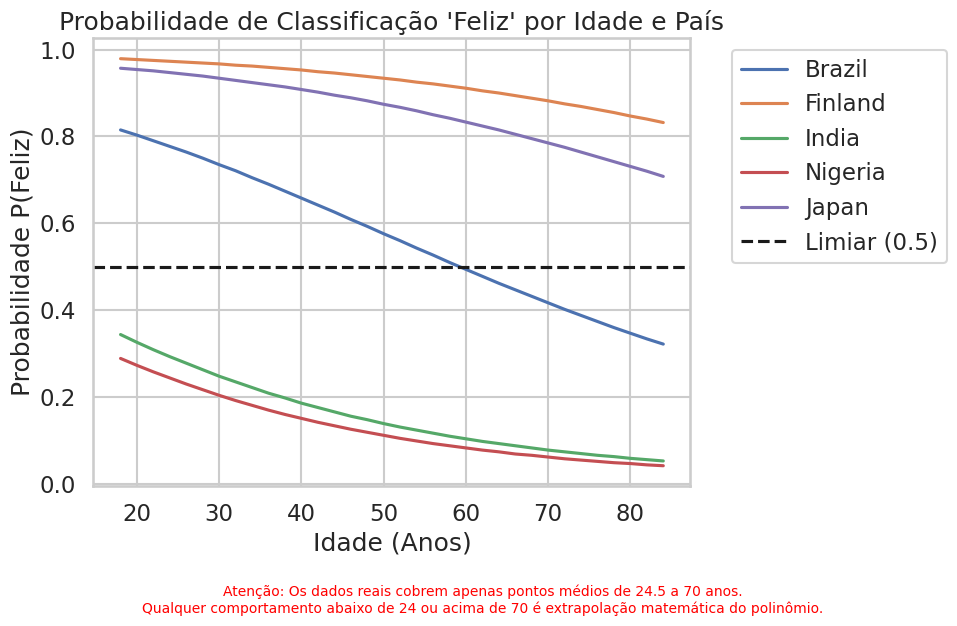

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Escolha de 5 países em faixas de renda e continentes diferentes
chosen = ["Brazil", "Finland", "India", "Nigeria", "Japan"]
ages = np.arange(18, 86, 2)

resultados = []
for c in chosen:
    for a in ages:
        try:
            res = check_happiness(c, a)
            resultados.append(res)
        except ValueError:
            pass

curves = pd.DataFrame(resultados)

# Visualização com Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=curves, x="age", y="p_happy", hue="country")

plt.axhline(0.5, ls="--", color="k", label="Limiar (0.5)")

# Aviso de extrapolação
plt.figtext(
    0.5, -0.05,
    "Atenção: Os dados reais cobrem apenas pontos médios de 24.5 a 70 anos.\nQualquer comportamento abaixo de 24 ou acima de 70 é extrapolação matemática do polinômio.",
    ha="center", fontsize=10, color="red"
)

plt.title("Probabilidade de Classificação 'Feliz' por Idade e País")
plt.ylabel("Probabilidade P(Feliz)")
plt.xlabel("Idade (Anos)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Um ponto estrutural para discutir. As quatro linhas de um país compartilham o mesmo PIB, a mesma população e a mesma área, então o modelo só consegue separá-las pela idade. Expliquem o que isso implica sobre o quanto o modelo realmente "sabe" sobre cada país.

**Minhas conclusões da Parte 4** (editem esta célula):Como o PIB, a população e a área são valores estáticos que se repetem nas quatro faixas etárias de um país, o modelo utiliza esses atributos econômicos apenas para definir a altura base da curva de felicidade daquela nação. O modelo não "sabe" como a riqueza é distribuída entre jovens e idosos; ele assume que o impacto econômico é igual para todos. Consequentemente, a única variável que empurra a probabilidade para cima ou para baixo ao longo do eixo horizontal é a idade. O formato da curva (a variação interna) é ditado exclusivamente pelos coeficientes da idade e da idade ao quadrado, enquanto os fatores socioeconômicos funcionam como um elevador que sobe ou desce o país inteiro no ranking global.


## Discussão

Respondam nesta célula. Usem as frases do Passo 0 e os resultados das Partes 3 e 4.
1. O perfil de idade **dentro dos países** mostra uma curva em U? Onde fica o mínimo? Como isso se compara ao artigo do WEF e ao resumo do WHR 2024?
2. Comparem o tamanho do efeito da idade com o do efeito da riqueza. Qual pesa mais para prever a nota de um país, e qual pesa mais para prever diferenças **dentro** de um país?
3. As linhas de vocês são médias de grupos por país, não indivíduos. Por que um padrão nas médias pode falhar em descrever qualquer pessoa em particular (a **falácia ecológica**)?
4. A idade aqui é o ponto médio de quatro faixas. Que informação isso descartou, e como uma curva em U poderia parecer diferente com idades em anos simples?
5. Uma fotografia de muitos países mistura **idade** com **coorte de nascimento**. O WHR 2024 encontra avaliações de vida menores em quem nasceu depois de 1980. Por que não dá para separar um efeito de idade de um efeito de coorte com um único corte transversal?
6. O que a escolha do limiar de "feliz" fez com os resultados de classificação, e vocês confiariam em um ponto de corte de probabilidade 0,5 para uma política pública?

**Respostas da dupla:**

1. Nos modelos gerados, o perfil de idade não demonstrou a clássica curva em U de forma visível; em vez disso, revelou uma tendência contínua de queda na probabilidade de felicidade. O mínimo matemático da regressão ficaria fora da faixa etária avaliada (acima dos 70 anos), sendo uma extrapolação. Isso contraria a generalização do artigo do WEF, que localiza o mínimo entre 20 e 40 anos apoiando-se em países de renda alta, mas corrobora o resumo do WHR 2024, que aponta a quebra desse padrão universal, evidenciando, por exemplo, a queda de felicidade entre os jovens na América do Norte.
2. A riqueza (log do PIB per capita) tem um peso drasticamente maior para prever a nota global e o patamar de um país, separando fortemente as nações ricas das pobres no eixo vertical. Contudo, para prever as diferenças dentro de um país neste conjunto de dados, a idade é a variável de maior peso absoluto. Como o PIB, a população e a área são repassados como valores estáticos para todas as quatro faixas etárias de uma mesma nação, a idade é a única variável que permite ao modelo diferenciar as linhas internamente.
3. A falácia ecológica ocorre quando inferimos o comportamento ou estado de um indivíduo com base na média do grupo ao qual ele pertence. Um padrão de média alta para o grupo de 30 a 44 anos de um país não descreve uma pessoa em particular porque a felicidade individual é afetada por inúmeras variáveis microeconômicas e psicológicas (como desemprego local, saúde mental ou luto) que desaparecem quando os dados são achatados em uma média nacional agregada.
4. Usar apenas quatro pontos médios (24.5, 37.0, 52.0 e 70.0) descarta toda a granularidade, os valores extremos e a variância interna das idades. Se o modelo fosse alimentado com idades em anos simples (20, 21, 22...), a curva poderia revelar pontos de inflexão precisos (por exemplo, um vale exato aos 47 anos e picos agudos em idades específicas), comportamentos não lineares que acabam suavizados e ocultados pelo agrupamento em amplos blocos de 15 anos.
5. Em um conjunto de dados de corte transversal (que tira uma "fotografia" de um período fixo, como 2021-2023), a idade e o ano de nascimento são matematicamente indissociáveis (Ano de Nascimento = Ano Atual da Pesquisa - Idade). Por causa dessa colinearidade perfeita, o modelo não consegue distinguir se a avaliação de vida menor de um grupo de 25 anos ocorre porque a juventude é uma fase psicologicamente difícil (efeito da idade) ou porque eles nasceram após 1980 e enfrentam um contexto histórico e econômico específico de sua geração (efeito de coorte).
6. A escolha do limiar baseado na mediana dividiu o banco de dados exatamente ao meio, forçando um balanceamento perfeito (50/50) entre as classes "feliz" e "não feliz". Isso impediu que o modelo viciasse as previsões para a classe majoritária e tornou a métrica de acurácia confiável. No entanto, um ponto de corte de 0,5 não serve para balizar políticas públicas. Ele é apenas uma fronteira matemática comparativa (estar na metade superior do mundo ou não); o bem-estar real não é binário. Políticas públicas exigem métricas contínuas e multidimensionais que identifiquem bolsões de extrema infelicidade ou necessidades específicas que uma probabilidade de "cara ou coroa" do algoritmo é incapaz de capturar.


### Citações
- [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx)
- [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/)
- [WHR 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/)
- [WHR 2024: Happiness of the younger, the older, and those in between](https://www.worldhappiness.report/ed/2024/happiness-of-the-younger-the-older-and-those-in-between/)
- [Our World in Data: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table)
- [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/)